Dataset shape: (4178, 8)

Running Elbow Method...


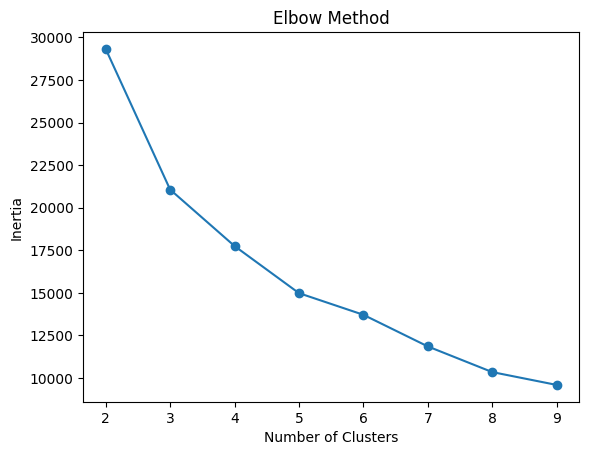

In [1]:
# -------------------------------------------------------
# Clustering Models + Model Evaluation
# Customer Segmentation Project
# -------------------------------------------------------

import pandas as pd
import numpy as np

from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn.decomposition import PCA

import matplotlib.pyplot as plt


# Load feature engineered data

df = pd.read_csv("C:\\Users\\gangu\\Desktop\\Project-demo\\customer-segmentation-unsupervised\\data\\processed\\processed_customer_data.csv", index_col=0)

print("Dataset shape:", df.shape)


# Scaling

scaler = StandardScaler()
scaled_data = scaler.fit_transform(df)

# 1. ELBOW METHOD (KMeans)


print("\nRunning Elbow Method...")

inertia = []

K_range = range(2, 10)

for k in K_range:
    model = KMeans(n_clusters=k, random_state=42)
    model.fit(scaled_data)
    inertia.append(model.inertia_)

plt.figure()
plt.plot(K_range, inertia, marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.show()


# Choose optimal clusters
# (Assume k = 4 based on elbow)

optimal_k = 4


# 2. KMeans Clustering

kmeans = KMeans(n_clusters=optimal_k, random_state=42)
kmeans_labels = kmeans.fit_predict(scaled_data)


# 3. Hierarchical Clustering

hierarchical = AgglomerativeClustering(n_clusters=optimal_k)
hier_labels = hierarchical.fit_predict(scaled_data)

# 4. DBSCAN Clustering

dbscan = DBSCAN(eps=0.5, min_samples=5)
dbscan_labels = dbscan.fit_predict(scaled_data)


# 5. Gaussian Mixture Model (GMM)

gmm = GaussianMixture(n_components=optimal_k, random_state=42)
gmm_labels = gmm.fit_predict(scaled_data)


# 6. Evaluation Function


def evaluate_model(name, data, labels):
    # DBSCAN may produce -1 (noise), handle carefully
    if len(set(labels)) > 1 and -1 not in set(labels):
        silhouette = silhouette_score(data, labels)
        db_index = davies_bouldin_score(data, labels)
    else:
        silhouette = -1
        db_index = -1

    print(f"\n{name} Results:")
    print(f"Clusters found: {len(set(labels))}")
    print(f"Silhouette Score: {silhouette:.4f}")
    print(f"Davies-Bouldin Index: {db_index:.4f}")









In [2]:

# 7. Evaluate All Models


evaluate_model("KMeans", scaled_data, kmeans_labels)
evaluate_model("Hierarchical", scaled_data, hier_labels)
evaluate_model("DBSCAN", scaled_data, dbscan_labels)
evaluate_model("GMM", scaled_data, gmm_labels)


KMeans Results:
Clusters found: 4
Silhouette Score: 0.2929
Davies-Bouldin Index: 1.0838

Hierarchical Results:
Clusters found: 4
Silhouette Score: 0.2730
Davies-Bouldin Index: 1.1448

DBSCAN Results:
Clusters found: 9
Silhouette Score: -1.0000
Davies-Bouldin Index: -1.0000

GMM Results:
Clusters found: 4
Silhouette Score: 0.0715
Davies-Bouldin Index: 1.8694


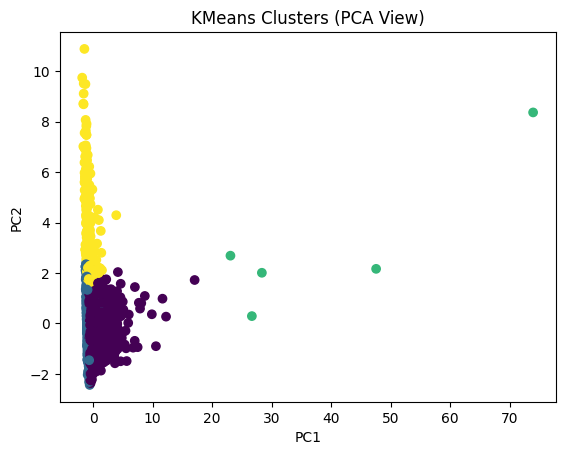

In [3]:

# 8. PCA Visualization


pca = PCA(n_components=2)
pca_data = pca.fit_transform(scaled_data)

pca_df = pd.DataFrame(pca_data, columns=['PC1', 'PC2'])

# Add labels
pca_df['KMeans'] = kmeans_labels

plt.figure()
plt.scatter(pca_df['PC1'], pca_df['PC2'], c=pca_df['KMeans'])
plt.title("KMeans Clusters (PCA View)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

In [6]:
# Save Results
df['Cluster'] = kmeans_labels
df.to_csv("final_clusters.csv")

print("\nClustering pipeline completed successfully.")


Clustering pipeline completed successfully.
